<a href="https://colab.research.google.com/github/NatanaelAnantaSatrio/SistemRekomendasi/blob/main/Praktikum4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORT LIBRARY

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

from math import sqrt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# LOAD DATASET

transactions = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/SistemRekomendasi/ecommerce_transactions.csv'
)

products = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/SistemRekomendasi/ecommerce_products.csv'
)

transactions.head()

,transaction_id,user_id,product_id,rating,quantity,total_price,timestamp
0,1,162,163,1,1,485.67,2026-03-12 03:02:48
1,2,792,12,2,3,766.23,2025-06-14 15:27:04
2,3,492,208,3,4,1678.88,2025-11-23 20:15:21
3,4,60,145,5,1,50.33,2026-01-21 17:14:31
4,5,520,79,3,2,149.68,2026-03-03 03:39:59


In [3]:
# EXPLORATORY DATA ANALYSIS

print(transactions.shape)

print(transactions.info())

print(transactions.describe())

(10000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  10000 non-null  int64  
 1   user_id         10000 non-null  int64  
 2   product_id      10000 non-null  int64  
 3   rating          10000 non-null  int64  
 4   quantity        10000 non-null  int64  
 5   total_price     10000 non-null  float64
 6   timestamp       10000 non-null  object 
dtypes: float64(1), int64(5), object(1)
memory usage: 547.0+ KB
None
       transaction_id       user_id    product_id        rating    quantity  \
count     10000.00000  10000.000000  10000.000000  10000.000000  10000.0000   
mean       5000.50000    502.370700    149.426800      3.009500      2.4948   
std        2886.89568    289.521616     86.522296      1.425557      1.1245   
min           1.00000      1.000000      1.000000      1.000000      1.0000   
25%        25

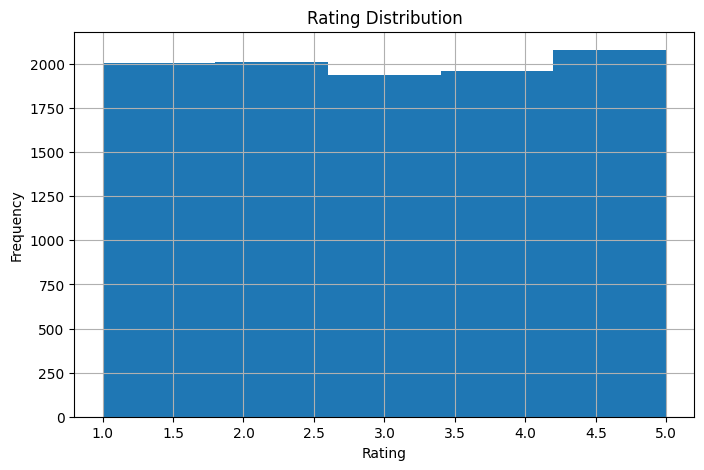

In [4]:
# DISTRIBUSI RATING

plt.figure(figsize=(8,5))

transactions['rating'].hist(
    bins=5
)

plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Distribution')

plt.show()

In [5]:
# MEMBUAT USER ITEM MATRIX

user_item_matrix = transactions.pivot_table(
    index='user_id',
    columns='product_id',
    values='rating'
)

user_item_matrix.head()

product_id,1,2,3,4,5,6,7,8,9,10,...,291,292,293,294,295,296,297,298,299,300
user_id,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# MENGISI MISSING VALUE

ratings = user_item_matrix.fillna(0).values

num_users, num_items = ratings.shape

print("Users :", num_users)
print("Items :", num_items)

Users : 1000
Items : 300


In [7]:
# PARAMETER PMF

K = 20

learning_rate = 0.01

regularization = 0.1

epochs = 50

In [8]:
# INISIALISASI LATENT MATRIX

U = np.random.normal(
    scale=1./K,
    size=(num_users, K)
)

V = np.random.normal(
    scale=1./K,
    size=(num_items, K)
)

In [9]:
# TRAINING PMF

training_process = []

for epoch in range(epochs):

    for i in range(num_users):

        for j in range(num_items):

            if ratings[i, j] > 0:

                prediction = np.dot(
                    U[i, :],
                    V[j, :].T
                )

                error = (
                    ratings[i, j]
                    - prediction
                )

                # UPDATE USER LATENT
                U[i, :] += learning_rate * (
                    error * V[j, :]
                    - regularization * U[i, :]
                )

                # UPDATE ITEM LATENT
                V[j, :] += learning_rate * (
                    error * U[i, :]
                    - regularization * V[j, :]
                )

    predicted_matrix = np.dot(
        U,
        V.T
    )

    mask = ratings > 0

    rmse = sqrt(
        mean_squared_error(
            ratings[mask],
            predicted_matrix[mask]
        )
    )

    training_process.append(rmse)

    print(
        f"Epoch {epoch+1}/{epochs}, RMSE: {rmse:.4f}"
    )

Epoch 1/50, RMSE: 3.3238
Epoch 2/50, RMSE: 3.3200
Epoch 3/50, RMSE: 3.3149
Epoch 4/50, RMSE: 3.3069
Epoch 5/50, RMSE: 3.2927
Epoch 6/50, RMSE: 3.2643
Epoch 7/50, RMSE: 3.2013
Epoch 8/50, RMSE: 3.0566
Epoch 9/50, RMSE: 2.7516
Epoch 10/50, RMSE: 2.2597
Epoch 11/50, RMSE: 1.7523
Epoch 12/50, RMSE: 1.4331
Epoch 13/50, RMSE: 1.2838
Epoch 14/50, RMSE: 1.2114
Epoch 15/50, RMSE: 1.1676
Epoch 16/50, RMSE: 1.1345
Epoch 17/50, RMSE: 1.1055
Epoch 18/50, RMSE: 1.0780
Epoch 19/50, RMSE: 1.0508
Epoch 20/50, RMSE: 1.0237
Epoch 21/50, RMSE: 0.9964
Epoch 22/50, RMSE: 0.9690
Epoch 23/50, RMSE: 0.9416
Epoch 24/50, RMSE: 0.9142
Epoch 25/50, RMSE: 0.8872
Epoch 26/50, RMSE: 0.8606
Epoch 27/50, RMSE: 0.8346
Epoch 28/50, RMSE: 0.8092
Epoch 29/50, RMSE: 0.7847
Epoch 30/50, RMSE: 0.7610
Epoch 31/50, RMSE: 0.7383
Epoch 32/50, RMSE: 0.7166
Epoch 33/50, RMSE: 0.6958
Epoch 34/50, RMSE: 0.6761
Epoch 35/50, RMSE: 0.6574
Epoch 36/50, RMSE: 0.6396
Epoch 37/50, RMSE: 0.6227
Epoch 38/50, RMSE: 0.6068
Epoch 39/50, RMSE: 0.

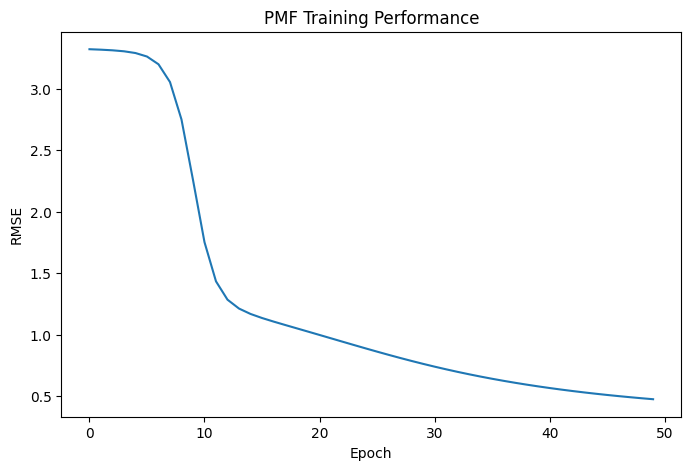

In [10]:
# TRAINING VISUALIZATION

plt.figure(figsize=(8,5))

plt.plot(training_process)

plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('PMF Training Performance')

plt.show()

In [11]:
# PREDICTED RATING MATRIX

predicted_ratings = np.dot(
    U,
    V.T
)

predicted_ratings

array([[3.3941444 , 3.69975423, 2.91067109, ..., 2.29006745, 3.83010251,
        2.53094355],
       [3.08276354, 1.47022791, 2.33100915, ..., 1.21949283, 1.94899556,
        1.16006883],
       [2.9740211 , 3.21500183, 2.99645112, ..., 1.92806986, 3.23183355,
        2.26063948],
       ...,
       [1.50826455, 1.33425638, 2.21739363, ..., 1.49029445, 2.13966786,
        1.28516148],
       [2.04435242, 1.35064859, 1.520825  , ..., 2.59853436, 3.77119678,
        3.09177492],
       [2.17347254, 2.67939358, 1.83444501, ..., 1.52995919, 2.39260811,
        0.61580202]])

In [12]:
# PREDIKSI SATU PRODUK

user_id = 1
product_id = 20

predicted_score = predicted_ratings[
    user_id-1,
    product_id-1
]

print(
    "Predicted Rating:",
    round(predicted_score, 3)
)

Predicted Rating: 3.02


In [13]:
# TOP K RECOMMENDATION

user_id = 5

user_predictions = predicted_ratings[
    user_id-1
]

top_items = np.argsort(
    user_predictions
)[::-1][:10]

recommendations = []

for item_index in top_items:

    product_id = user_item_matrix.columns[
        item_index
    ]

    score = user_predictions[
        item_index
    ]

    recommendations.append(
        (product_id, score)
    )

recommendations

[(np.int64(237), np.float64(4.750258390751433)),
 (np.int64(182), np.float64(4.607237174295237)),
 (np.int64(15), np.float64(4.573421494128492)),
 (np.int64(113), np.float64(4.432900132138417)),
 (np.int64(179), np.float64(4.320568860007819)),
 (np.int64(218), np.float64(4.229723187098985)),
 (np.int64(2), np.float64(4.228252876033375)),
 (np.int64(299), np.float64(4.141178085893224)),
 (np.int64(153), np.float64(4.105747044735319)),
 (np.int64(144), np.float64(4.084121639576316))]

In [14]:
# MENAMPILKAN NAMA PRODUK

for product_id, score in recommendations:

    product_name = products[
        products['product_id']
        == product_id
    ]['product_name'].values[0]

    print(
        product_name,
        "| Score:",
        round(score, 2)
    )

Electronics Product 237 | Score: 4.75
Sports Product 182 | Score: 4.61
Fashion Product 15 | Score: 4.57
Sports Product 113 | Score: 4.43
Beauty Product 179 | Score: 4.32
Fashion Product 218 | Score: 4.23
Books Product 2 | Score: 4.23
Beauty Product 299 | Score: 4.14
Home Product 153 | Score: 4.11
Beauty Product 144 | Score: 4.08


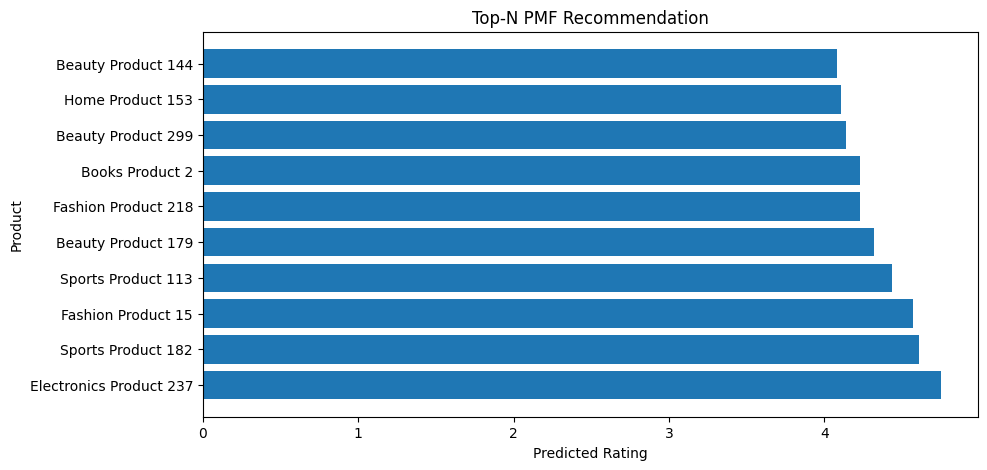

In [16]:
# VISUALISASI REKOMENDASI

product_names = []
scores = []

for product_id, score in recommendations:

    product_name = products[
        products['product_id']
        == product_id
    ]['product_name'].values[0]

    product_names.append(product_name)

    scores.append(score)

plt.figure(figsize=(10,5))

plt.barh(
    product_names,
    scores
)

plt.xlabel('Predicted Rating')
plt.ylabel('Product')
plt.title('Top-N PMF Recommendation')

plt.show()

In [17]:
# EVALUASI MODEL

mask = ratings > 0

rmse = sqrt(
    mean_squared_error(
        ratings[mask],
        predicted_ratings[mask]
    )
)

mae = mean_absolute_error(
    ratings[mask],
    predicted_ratings[mask]
)

print("RMSE :", round(rmse, 4))
print("MAE  :", round(mae, 4))

RMSE : 0.4729
MAE  : 0.3838


In [18]:
# PRECISION@K

K = 10

relevant_items = 0

for item, score in recommendations:

    if score >= 4:
        relevant_items += 1

precision_at_k = relevant_items / K

print(
    "Precision@K:",
    round(precision_at_k, 4)
)

Precision@K: 1.0
